<a href="https://colab.research.google.com/github/caions6/Aula-1-Processamento-de-Sinais-/blob/main/Aula_2_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Para um sinal x(t) = cos(2πft) amostrado com fs =
44.1 kHz, fa¸ca o que se pede nos itens abaixo:

(a) Utilizando a fun¸c˜ao calculate_spectrum(), calcule
o espectro de x(t) para f ∈ {500, 5000, 10000, 50000} Hz.


(b) Comente os resultados obtidos.

In [3]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

In [10]:
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
        # Double the amplitude for single-sided (except DC and Nyquist)
        amplitudes[1:] *= 2
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

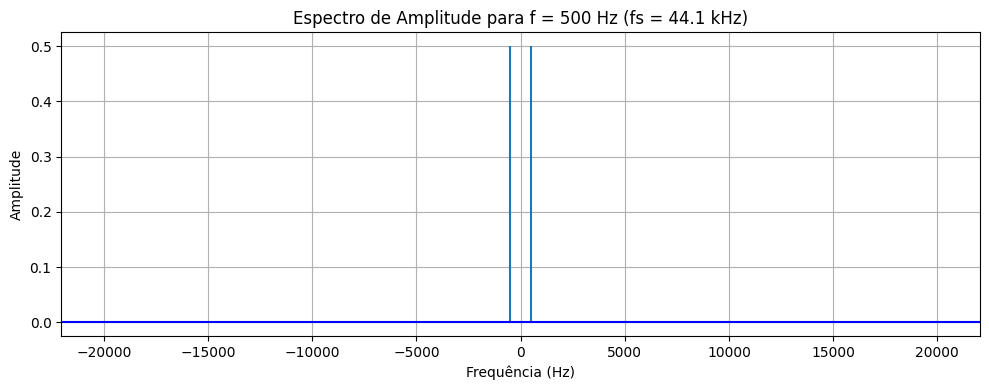

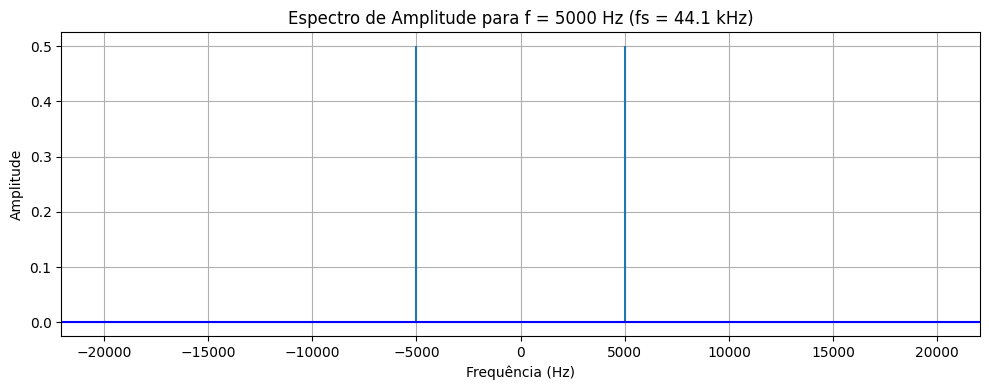

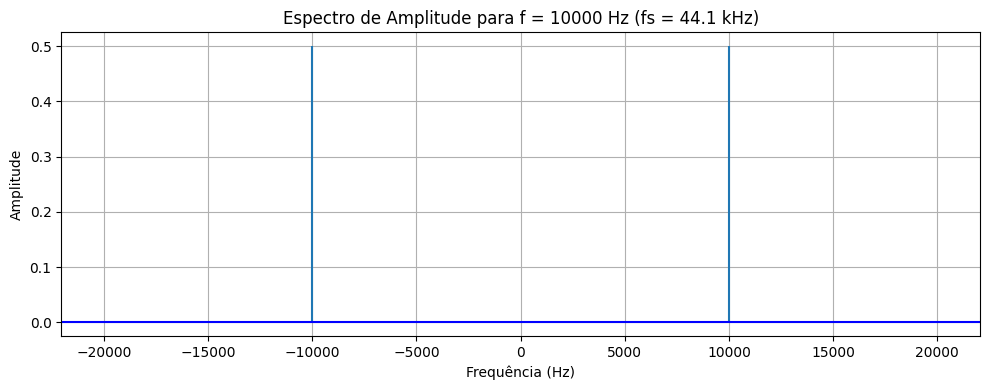

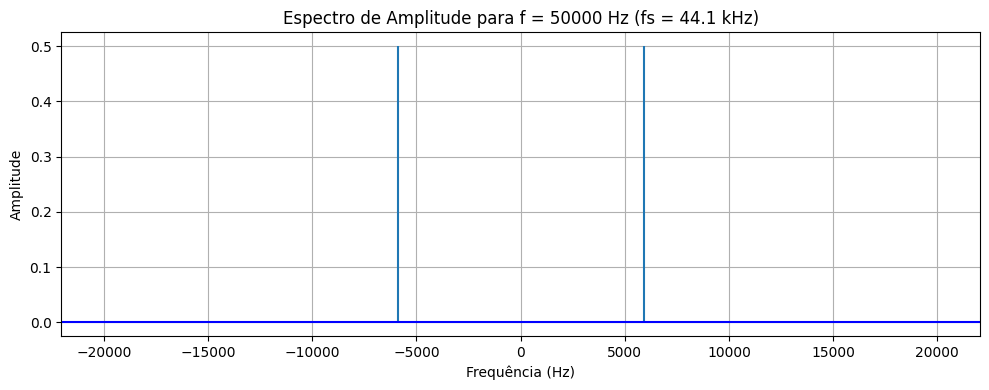

In [11]:
fs = 44100  # 44.1 kHz
frequencies = [500, 5000, 10000, 50000]
t_end = 0.05 # Reduzido para melhor visualização temporal se necessário
t = np.arange(0, t_end, 1/fs)

for f in frequencies:
    # Gerando o sinal x(t) = cos(2*pi*f*t)
    x = np.cos(2 * np.pi * f * t)

    # Calculando o espectro
    xf, amp = calculate_spectrum(x, fs, single_sided=False)

    # Plotando
    plt.figure(figsize=(10, 4))
    plt.stem(xf, amp, markerfmt=" ", basefmt="-b")
    plt.title(f'Espectro de Amplitude para f = {f} Hz (fs = {fs/1000} kHz)')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.xlim([-fs/2, fs/2]) # Focar na zona de Nyquist
    plt.tight_layout()
    plt.show()

### Resposta do Item (b) - Comentários sobre os resultados

O experimento demonstra o **Teorema de Amostragem de Nyquist-Shannon**, que estabelece que a frequência de amostragem $f_s$ deve ser maior que o dobro da maior frequência do sinal ($f_{max}$) para evitar perda de informação.

*   **Dentro do limite ($f < f_s/2$):** Para os casos de **500 Hz, 5.000 Hz e 10.000 Hz**, os sinais estão abaixo de $22.050$ Hz ($44.100 / 2$). O espectro mostra os picos exatamente nas frequências corretas.
*   **Acima do limite ($f > f_s/2$):** Para o caso de **50.000 Hz**, ocorre o **Aliasing**. Como a frequência ultrapassa o limite de Nyquist, ela é "rebatida" para dentro da banda base. A frequência aparente observada é dada por:
    $$f_{alias} = |f - k \cdot f_s|$$
    Para $k=1$: $|50.000 - 44.100| = 5.900$ Hz. Por isso, no último gráfico, o pico aparece próximo a 5.9 kHz em vez de 50 kHz.

2. Para um chirp com frequˆencia inicial f0 = 500 Hz,
frequˆencia final f1 = 10000 Hz, amostrado com fs =
44.1 kHz, fa¸ca o que se pede nos itens abaixo:

(a) Utilizando a fun¸c˜ao calculate_spectrum(), calcule
o espectro do chirp com varreduras de frequˆencia lineares,
quadr´aticas e logar´ıtmicas.

(b) Comente os resultados obtidos.

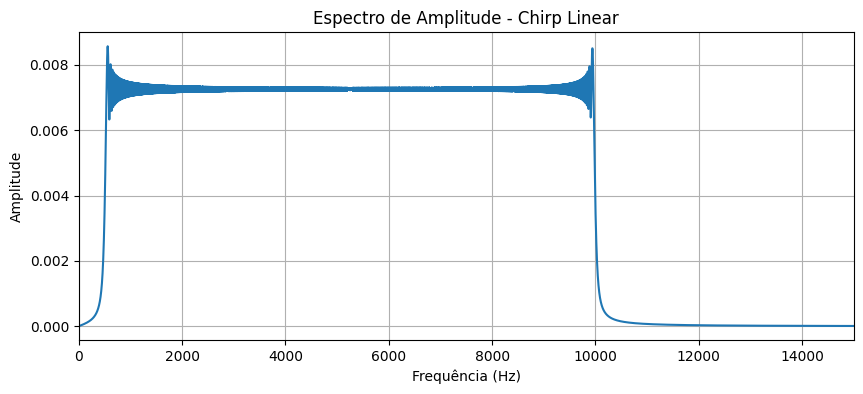

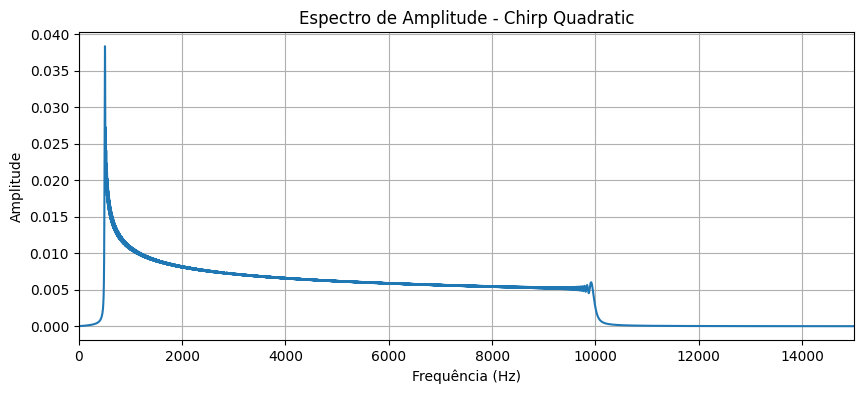

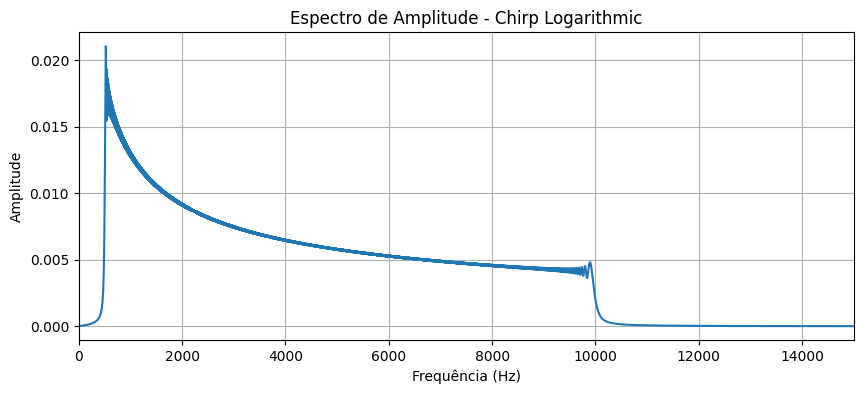

In [12]:
from scipy.signal import chirp

fs = 44100
t_end = 2.0  # Duração de 2 segundos para melhor resolução espectral
t = np.arange(0, t_end, 1/fs)
f0 = 500
f1 = 10000

methods = ["linear", "quadratic", "logarithmic"]

for method in methods:
    # Gerando o sinal chirp
    signal = chirp(t, f0=f0, f1=f1, t1=t_end, method=method)

    # Calculando o espectro
    xf, amp = calculate_spectrum(signal, fs, single_sided=True)

    # Plotando
    plt.figure(figsize=(10, 4))
    plt.plot(xf, amp)
    plt.title(f"Espectro de Amplitude - Chirp {method.capitalize()}")
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.xlim([0, 15000]) # Foco na banda de interesse
    plt.show()

### Resposta do Item 2 (b) - Comentários sobre os resultados

*   **Chirp Linear:** A energia é distribuída de forma aproximadamente uniforme entre 500 Hz e 10.000 Hz. Isso ocorre porque a frequência varia a uma taxa constante, passando a mesma quantidade de tempo em cada intervalo de frequência.
*   **Chirp Quadrático:** A energia tende a se concentrar mais nas frequências mais altas. Como a variação da frequência acelera ao longo do tempo, o sinal passa proporcionalmente mais tempo nas faixas de frequência superiores antes de atingir o limite final.
*   **Chirp Logarítmico:** Apresenta uma distribuição de energia que favorece as frequências mais baixas no espectro linear. No domínio logarítmico, essa variação pareceria mais uniforme, mas no gráfico linear, vemos que ele 'varre' as frequências iniciais mais lentamente do que as finais.

Em todos os casos, como a frequência máxima (10 kHz) é menor que o limite de Nyquist (22,05 kHz), não observamos aliasing significante.

3. Leia o arquivo handel.wav e fa¸ca o que se pede nos
itens abaixo:

(a) Utilizando a fun¸c˜ao calculate_spectrum(), calcule
o espectro do sinal de ´audio.

(b) Comente os resultados obtidos.

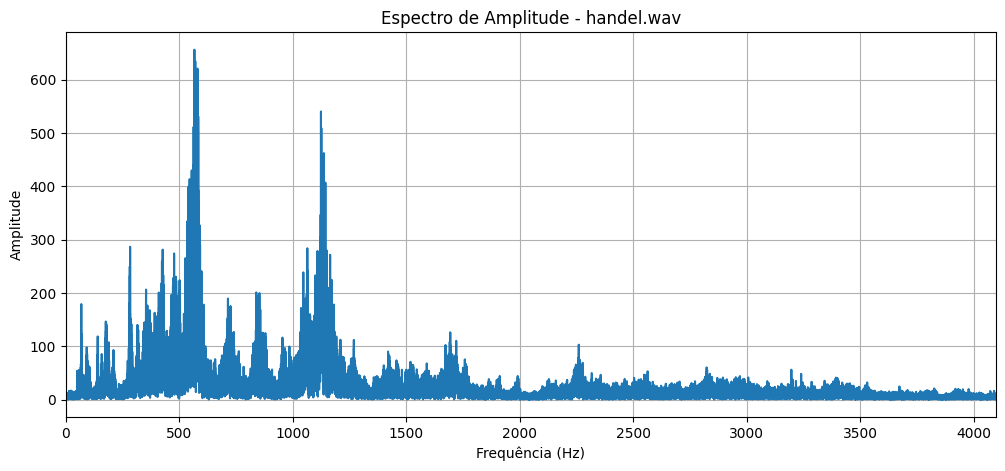

In [13]:
from scipy.io import wavfile

# Lendo o arquivo de áudio
samplerate, data = wavfile.read('/content/handel.wav')

# Se for estéreo (2 colunas), pegamos apenas um canal
if len(data.shape) > 1:
    data = data[:, 0]

# Normalizando o sinal e calculando o espectro
xf_audio, amp_audio = calculate_spectrum(data, samplerate, single_sided=True)

# Plotando o espectro do áudio
plt.figure(figsize=(12, 5))
plt.plot(xf_audio, amp_audio)
plt.title('Espectro de Amplitude - handel.wav')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim([0, samplerate/2]) # Exibir até o limite de Nyquist do arquivo
plt.show()

### Resposta do Item 3 (b) - Comentários sobre os resultados

*   **Conteúdo Harmônico:** Diferente dos tons puros ou chirps, o espectro do sinal 'Handel' é complexo, apresentando uma vasta gama de frequências sobrepostas que compõem a música.
*   **Decaimento de Energia:** É possível observar que a maior parte da energia está concentrada em frequências mais baixas e médias (frequências fundamentais dos instrumentos e vozes), com a amplitude diminuindo conforme a frequência aumenta.
*   **Taxa de Amostragem:** O espectro se estende até a metade da `samplerate` do arquivo original. Como é um áudio de música, as componentes de alta frequência são essenciais para a 'brilho' e fidelidade do som.

4. Subamostrar um sinal x[n] por um fator de M ´e o
mesmo que reduzir sua taxa de amostragem em M vezes.
A rela¸c˜ao entre o sinal subamostrado e o sinal original ´e
dada por
y[n] = x[nM].
Para o arquivo handel.wav, fa¸ca o que se pede nos itens
abaixo:

(a) Crie uma fun¸c˜ao para realizar a subamostragem de
um sinal discreto.

(b) Utilizando a fun¸c˜ao criada, realize a subamostragem
do sinal de ´audio por fator de M ∈ {2, 4, 8}.

(c) Utilizando a fun¸c˜ao calculate_spectrum(), calcule
o espectro do sinal subamostrado.

(d) Ou¸ca os sinais subamostrados.

(e) Comente os resultados obtidos.

In [20]:
def downsample(signal, M):
    """
    Reduces the sampling rate of a discrete signal by an integer factor M.

    Args:
        signal (np.ndarray): The original discrete signal x[n].
        M (int): The downsampling factor.

    Returns:
        np.ndarray: The downsampled signal y[n] = x[nM].
    """
    # Slicing the array from 0 with step M
    return signal[::M]

# Quick test of the function definition
test_signal = [0, 1, 2, 3, 4, 5]
print(f"Original: {test_signal}")
print(f"Downsampled (M=2): {downsample(test_signal, 2)}")

Original: [0, 1, 2, 3, 4, 5]
Downsampled (M=2): [0, 2, 4]


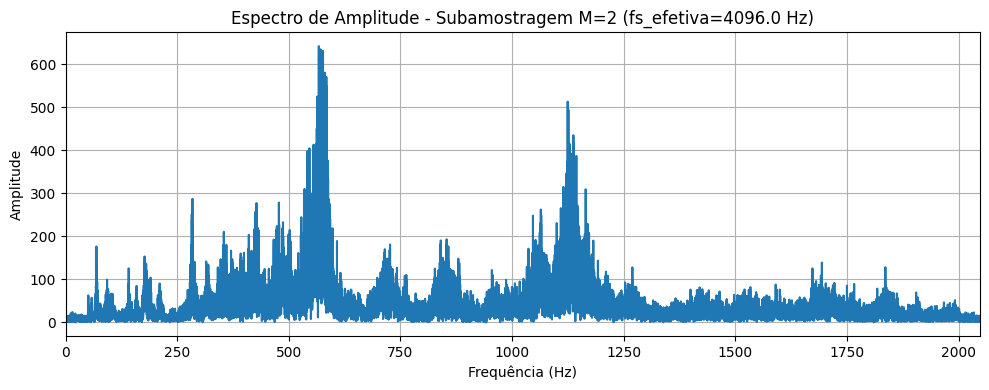

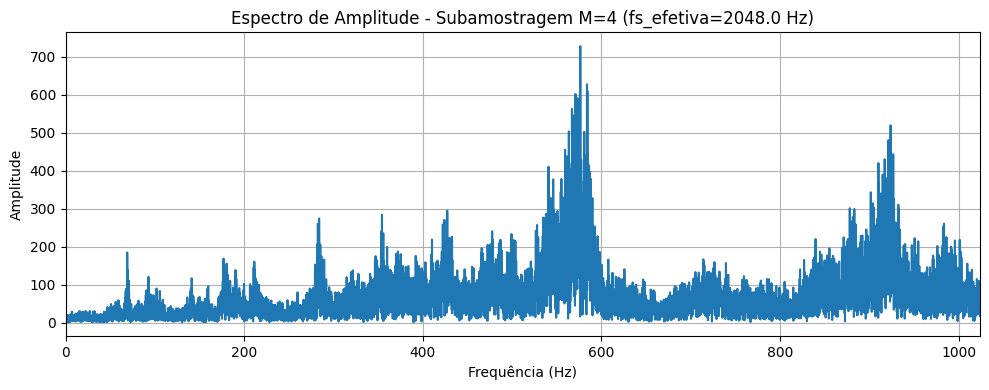

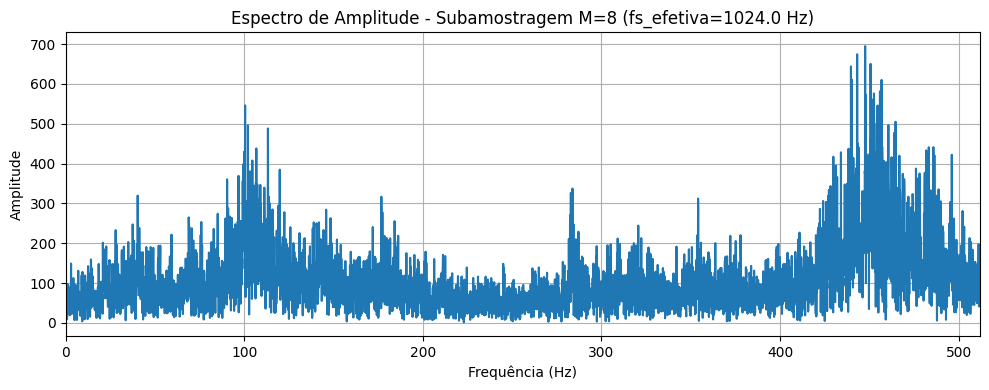

In [21]:
M_values = [2, 4, 8]

for M in M_values:
    # 3. Call the downsample function
    downsampled_signal = downsample(data, M)

    # 4. Calculate new effective sampling rate
    new_fs = samplerate / M

    # 5. Calculate the spectrum
    xf_down, amp_down = calculate_spectrum(downsampled_signal, new_fs, single_sided=True)

    # 6. Create a plot for each downsampled spectrum
    plt.figure(figsize=(10, 4))
    plt.plot(xf_down, amp_down)
    plt.title(f'Espectro de Amplitude - Subamostragem M={M} (fs_efetiva={new_fs} Hz)')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)

    # 7. Set x-axis limits to the new Nyquist frequency
    plt.xlim([0, new_fs / 2])

    # 8. Display the plot
    plt.tight_layout()
    plt.show()

In [34]:
from IPython.display import Audio, display

# Função auxiliar para garantir a exibição
def play(audio_signal, fs, title):
    print(f"\n{title}")
    display(Audio(data=audio_signal, rate=int(fs)))

# 1. Áudio Original
play(data, samplerate, "--- Áudio Original (8192 Hz) ---")

# 2. Subamostrado M=2
data_m2 = downsample(data, 2)
play(data_m2, samplerate/2, "--- Subamostrado M=2 (4096 Hz) ---")

# 3. Subamostrado M=4
data_m4 = downsample(data, 4)
play(data_m4, samplerate/4, "--- Subamostrado M=4 (2048 Hz) ---")

# 4. Subamostrado M=8
data_m8 = downsample(data, 8)
play(data_m8, samplerate/8, "--- Subamostrado M=8 (1024 Hz) ---")


--- Áudio Original (8192 Hz) ---



--- Subamostrado M=2 (4096 Hz) ---



--- Subamostrado M=4 (2048 Hz) ---



--- Subamostrado M=8 (1024 Hz) ---


### Resposta do Item 4 (e) - Comentários sobre os resultados da Subamostragem

*   **Perda de Fidelidade e Brilho:** À medida que o fator de subamostragem $M$ aumenta, a taxa de amostragem efetiva diminui ($f_s/M$). Isso resulta na perda imediata de componentes de alta frequência (o 'brilho' do som), pois o limite de Nyquist se torna cada vez menor.
*   **Presença de Aliasing:** Como o sinal original não foi filtrado por um filtro passa-baixas antes da subamostragem (decimação sem filtragem anti-aliasing), as componentes de frequência que estavam acima do novo limite de Nyquist são 'rebatidas' para frequências mais baixas. Isso introduz ruídos metálicos e distorções características no áudio.
*   **Comparação Visual:** Nos espectros calculados, observamos que o eixo de frequência encolhe para cada $M$. O espectro parece 'esticado' e preenche a nova banda disponível, mas na verdade, as frequências altas do sinal original agora aparecem como ruído de aliasing sobreposto às frequências baixas.
*   **Impacto Auditivo:** Em $M=2$, o áudio ainda é reconhecível mas 'abafado'. Em $M=8$, a taxa de amostragem cai para cerca de 1024 Hz (Nyquist de 512 Hz), tornando a música quase irreconhecível e dominada por ruído de baixa frequência.